In [2]:
# Binary Classification Model for MIT-BIH (Normal vs Arrhythmia)
# Modified from the original arxiv-1805-00794 model
# This version matches the canine transfer learning approach:
# - Binary task: N (0) vs Arrhythmia (1) where Arrhythmia = S + V
# - Same architecture as original but with binary output

import math
import random
import pickle
import itertools

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_curve, auc, roc_auc_score, roc_curve
)

from sklearn.utils import shuffle

from scipy.signal import resample

import matplotlib.pyplot as plt

np.random.seed(42)

import pickle
from sklearn.preprocessing import OneHotEncoder

from keras.models import Model
from keras.layers import Input, Dense, Conv1D, MaxPooling1D, Softmax, Add, Flatten, Activation
from keras import backend as K
from keras.optimizers import Adam
from keras.callbacks import LearningRateScheduler, ModelCheckpoint

import os
print("Available data files:")
print(os.listdir(r"../Data"))

# Binary classification configuration
BINARY_MODE = True  # N (0) vs Arrhythmia (1) 
INCLUDE_S_BEATS = True  # Include S-beats as arrhythmia (matches canine approach)

Available data files:
['mitbih_test.csv', 'mitbih_train.csv']


In [3]:
df = pd.read_csv(r"../Data/mitbih_train.csv", header=None)
df2 = pd.read_csv(r"../Data/mitbih_test.csv", header=None)
df = pd.concat([df, df2], axis=0)

In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109446 entries, 0 to 21891
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 157.8 MB


In [6]:
df[187].value_counts()

187
0.0    90589
4.0     8039
2.0     7236
1.0     2779
3.0      803
Name: count, dtype: int64

In [8]:
M = df.values
X = M[:, :-1]
y_orig = M[:, -1].astype(int)

print(f"Original label distribution: {dict(zip(*np.unique(y_orig, return_counts=True)))}")

# Binary remapping: N vs Arrhythmia (S + V)
# Keep only N (0), S (1), V (2)
# Map to: N=0, Arrhythmia=1
if INCLUDE_S_BEATS:
    normal_classes = [0]  # N
    arrhythmia_classes = [1, 2]  # S, V
    keep_classes = normal_classes + arrhythmia_classes
else:
    # Original N vs V only
    keep_classes = [0, 2]
    arrhythmia_classes = [2]

# Filter to keep only relevant classes
mask = np.isin(y_orig, keep_classes)
X = X[mask]
y_orig = y_orig[mask]

# Binary remap: Normal=0, Arrhythmia=1
if INCLUDE_S_BEATS:
    y = np.isin(y_orig, arrhythmia_classes).astype(np.int64)
else:
    y = (y_orig == 2).astype(np.int64)

print(f"\nAfter binary remapping:")
print(f"  Original classes kept: {dict(zip(*np.unique(y_orig, return_counts=True)))}")
print(f"  Binary mapping: {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"  Total samples: {len(y)}")
print(f"  Normal (0): {np.sum(y == 0)} samples ({100*np.mean(y==0):.1f}%)")
print(f"  Arrhythmia (1): {np.sum(y == 1)} samples ({100*np.mean(y==1):.1f}%)")

Original label distribution: {np.int64(0): np.int64(90589), np.int64(1): np.int64(2779), np.int64(2): np.int64(7236), np.int64(3): np.int64(803), np.int64(4): np.int64(8039)}

After binary remapping:
  Original classes kept: {np.int64(0): np.int64(90589), np.int64(1): np.int64(2779), np.int64(2): np.int64(7236)}
  Binary mapping: {np.int64(0): np.int64(90589), np.int64(1): np.int64(10015)}
  Total samples: 100604
  Normal (0): 90589 samples (90.0%)
  Arrhythmia (1): 10015 samples (10.0%)


In [9]:
del df
del df2
del M

# Binary Classification: Normal vs Arrhythmia
# N (0) = Normal
# S (1) + V (2) = Arrhythmia (combined as class 1)
# F (3) and Q (4) will be dropped to match canine approach

In [10]:
# For binary classification, we have only two classes
C0 = np.argwhere(y == 0).flatten()  # Normal
C1 = np.argwhere(y == 1).flatten()  # Arrhythmia (S + V combined)

print(f"Class 0 (Normal): {len(C0)} samples")
print(f"Class 1 (Arrhythmia): {len(C1)} samples")

Class 0 (Normal): 90589 samples
Class 1 (Arrhythmia): 10015 samples


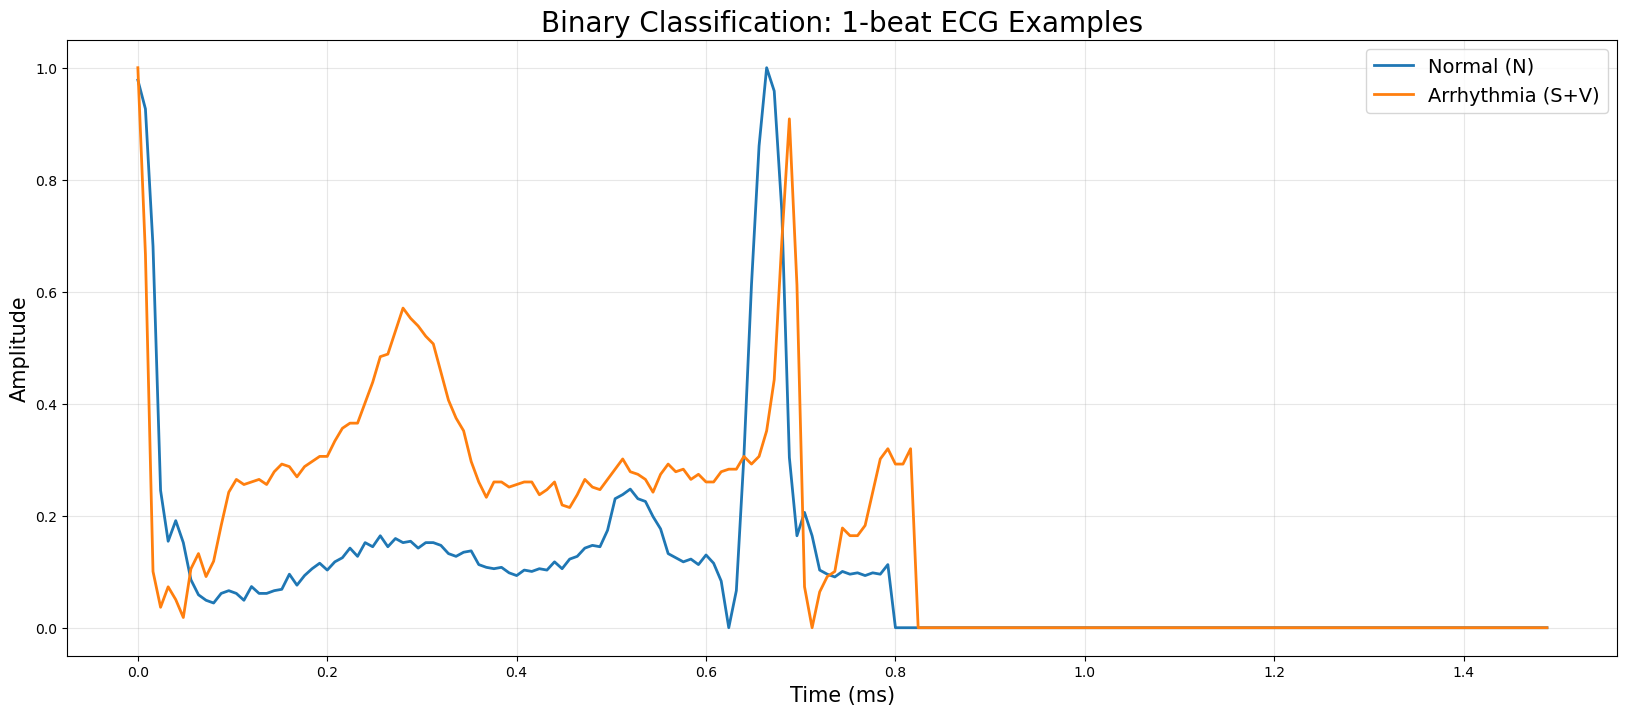

In [11]:
x = np.arange(0, 187)*8/1000

plt.figure(figsize=(20,8))
plt.plot(x, X[C0, :][0], label="Normal (N)", linewidth=2)
plt.plot(x, X[C1, :][0], label="Arrhythmia (S+V)", linewidth=2)
plt.legend(fontsize=14)
plt.title("Binary Classification: 1-beat ECG Examples", fontsize=20)
plt.ylabel("Amplitude", fontsize=15)
plt.xlabel("Time (ms)", fontsize=15)
plt.grid(True, alpha=0.3)
plt.show()

# Data augmentation for minority class (Arrhythmia)
# Augment arrhythmia class to balance the dataset better

In [12]:
def stretch(x):
    l = int(187 * (1 + (random.random()-0.5)/3))
    y = resample(x, l)
    if l < 187:
        y_ = np.zeros(shape=(187, ))
        y_[:l] = y
    else:
        y_ = y[:187]
    return y_

def amplify(x):
    alpha = (random.random()-0.5)
    factor = -alpha*x + (1+alpha)
    return x*factor

def augment(x):
    result = np.zeros(shape= (4, 187))
    for i in range(3):
        if random.random() < 0.33:
            new_y = stretch(x)
        elif random.random() < 0.66:
            new_y = amplify(x)
        else:
            new_y = stretch(x)
            new_y = amplify(new_y)
        result[i, :] = new_y
    return result

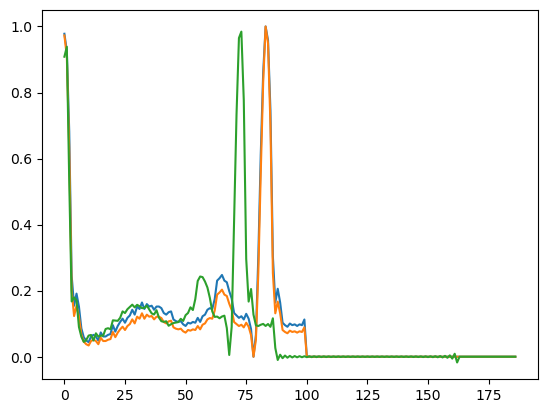

In [13]:
plt.plot(X[0, :])
plt.plot(amplify(X[0, :]))
plt.plot(stretch(X[0, :]))
plt.show()

In [14]:
# Augment arrhythmia class (minority class) to improve balance
result = np.apply_along_axis(augment, axis=1, arr=X[C1]).reshape(-1, 187)
classe = np.ones(shape=(result.shape[0],), dtype=int)  # All arrhythmia (1)
X = np.vstack([X, result])
y = np.hstack([y, classe])

print(f"After augmentation:")
print(f"  Total samples: {len(y)}")
print(f"  Normal (0): {np.sum(y == 0)} samples ({100*np.mean(y==0):.1f}%)")
print(f"  Arrhythmia (1): {np.sum(y == 1)} samples ({100*np.mean(y==1):.1f}%)")

After augmentation:
  Total samples: 140664
  Normal (0): 90589 samples (64.4%)
  Arrhythmia (1): 50075 samples (35.6%)


# Train/Test Split for Binary Classification

In [15]:
# Recalculate indices after augmentation
C0 = np.argwhere(y == 0).flatten()
C1 = np.argwhere(y == 1).flatten()

# Balanced test set: 1600 samples per class
n_test_per_class = 1600
subC0 = np.random.choice(C0, n_test_per_class)
subC1 = np.random.choice(C1, n_test_per_class)

In [16]:
X_test = np.vstack([X[subC0], X[subC1]])
y_test = np.hstack([y[subC0], y[subC1]])

X_train = np.delete(X, [subC0, subC1], axis=0)
y_train = np.delete(y, [subC0, subC1], axis=0)

X_train, y_train = shuffle(X_train, y_train, random_state=0)
X_test, y_test = shuffle(X_test, y_test, random_state=0)

print(f"Training set:")
print(f"  Total: {len(y_train)} samples")
print(f"  Normal (0): {np.sum(y_train == 0)} ({100*np.mean(y_train==0):.1f}%)")
print(f"  Arrhythmia (1): {np.sum(y_train == 1)} ({100*np.mean(y_train==1):.1f}%)")

print(f"\nTest set:")
print(f"  Total: {len(y_test)} samples")
print(f"  Normal (0): {np.sum(y_test == 0)} ({100*np.mean(y_test==0):.1f}%)")
print(f"  Arrhythmia (1): {np.sum(y_test == 1)} ({100*np.mean(y_test==1):.1f}%)")

del X
del y

Training set:
  Total: 137510 samples
  Normal (0): 89001 (64.7%)
  Arrhythmia (1): 48509 (35.3%)

Test set:
  Total: 3200 samples
  Normal (0): 1600 (50.0%)
  Arrhythmia (1): 1600 (50.0%)


In [17]:
X_train = np.expand_dims(X_train, 2)
X_test = np.expand_dims(X_test, 2)

In [18]:
print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test", X_test.shape)
print("y_test", y_test.shape)

X_train (137510, 187, 1)
y_train (137510,)
X_test (3200, 187, 1)
y_test (3200,)


In [19]:
# For binary classification, no one-hot encoding needed
# Keep labels as integers: 0 = Normal, 1 = Arrhythmia
# We'll use binary_crossentropy with sigmoid activation

print("Using integer labels for binary classification")
print("y_train:", y_train.shape, y_train.dtype)
print("y_test:", y_test.shape, y_test.dtype)

Using integer labels for binary classification
y_train: (137510,) int64
y_test: (3200,) int64


In [20]:
print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test", X_test.shape)
print("y_test", y_test.shape)

X_train (137510, 187, 1)
y_train (137510,)
X_test (3200, 187, 1)
y_test (3200,)


# Binary Classification Model
# Same architecture as original but with binary output (sigmoid instead of softmax)

In [21]:
n_obs, feature, depth = X_train.shape
batch_size = 500

In [22]:
K.clear_session()

inp = Input(shape=(feature, depth))
C = Conv1D(filters=32, kernel_size=5, strides=1)(inp)

# Residual Block 1
C11 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(C)
A11 = Activation("relu")(C11)
C12 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A11)
S11 = Add()([C12, C])
A12 = Activation("relu")(S11)
M11 = MaxPooling1D(pool_size=5, strides=2)(A12)

# Residual Block 2
C21 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M11)
A21 = Activation("relu")(C21)
C22 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A21)
S21 = Add()([C22, M11])
A22 = Activation("relu")(S21)
M21 = MaxPooling1D(pool_size=5, strides=2)(A22)

# Residual Block 3
C31 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M21)
A31 = Activation("relu")(C31)
C32 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A31)
S31 = Add()([C32, M21])
A32 = Activation("relu")(S31)
M31 = MaxPooling1D(pool_size=5, strides=2)(A32)

# Residual Block 4
C41 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M31)
A41 = Activation("relu")(C41)
C42 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A41)
S41 = Add()([C42, M31])
A42 = Activation("relu")(S41)
M41 = MaxPooling1D(pool_size=5, strides=2)(A42)

# Residual Block 5
C51 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M41)
A51 = Activation("relu")(C51)
C52 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A51)
S51 = Add()([C52, M41])
A52 = Activation("relu")(S51)
M51 = MaxPooling1D(pool_size=5, strides=2)(A52)

# Flatten and Dense layers
F1 = Flatten()(M51)
D1 = Dense(32)(F1)
A6 = Activation("relu")(D1)
D2 = Dense(32)(A6)

# Binary output: Single neuron with sigmoid activation
D3 = Dense(1)(D2)  # Changed from Dense(5) to Dense(1)
A7 = Activation("sigmoid")(D3)  # Changed from Softmax to sigmoid

model = Model(inputs=inp, outputs=A7)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 183, 32)   │        192 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 183, 32)   │      5,152 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 183, 32)   │          0 │ conv1d_1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 183, 32)   │      5,152 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 183, 32)   │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 183, 32)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 90, 32)    │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 90, 32)    │      5,152 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 90, 32)    │          0 │ conv1d_3[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 90, 32)    │      5,152 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 90, 32)    │          0 │ conv1d_4[0][0],   │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 90, 32)    │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 43, 32)    │          0 │ activation_3[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 43, 32)    │      5,152 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 43, 32)    │          0 │ conv1d_5[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 43, 32)    │      5,152 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 43, 32)    │          0 │ conv1d_6[0][0],   │
│                     │                   │            │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 43, 32)    │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                 

 Total params: 54,881 (214.38 KB)

 Trainable params: 54,881 (214.38 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
def exp_decay(epoch):
    initial_lrate = 0.001
    k = 0.75
    t = n_obs//(10000 * batch_size)  # every epoch we do n_obs/batch_size iteration
    lrate = initial_lrate * math.exp(-k*t)
    return lrate

lrate = LearningRateScheduler(exp_decay)

In [24]:
adam = Adam(learning_rate = 0.001, beta_1 = 0.9, beta_2 = 0.999)

In [25]:
# Remove the complex data processing - we already have the correct format
# X_train and X_test are already (N, 187, 1) shape
# y_train and y_test are already binary integers (0 or 1)

print("X_train:", X_train.shape, X_train.dtype)
print("X_test :", X_test.shape, X_test.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("y_test :", y_test.shape, y_test.dtype)

X_train: (137510, 187, 1) float64
X_test : (3200, 187, 1) float64
y_train: (137510,) int64
y_test : (3200,) int64


In [26]:
# Compile with binary crossentropy and metrics suitable for binary classification
from tensorflow.keras.metrics import AUC, Precision, Recall

model.compile(
    loss='binary_crossentropy',
    optimizer=adam,
    metrics=[
        'accuracy',
        AUC(name='auc'),
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

print("Model compiled for binary classification with binary_crossentropy loss")

Model compiled for binary classification with binary_crossentropy loss


In [27]:
# Train the binary classification model
# Save best model checkpoint
checkpoint = ModelCheckpoint(
    r"best_model_binary.h5",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

history = model.fit(
    X_train, y_train, 
    epochs=75, 
    batch_size=batch_size, 
    verbose=2, 
    validation_data=(X_test, y_test), 
    callbacks=[lrate, checkpoint]
)

print("\nTraining completed!")
print(f"Best model saved to: best_model_binary.h5")

Epoch 1/75

Epoch 1: val_loss improved from None to 0.14934, saving model to best_model_binary.h5


276/276 - 6s - 23ms/step - accuracy: 0.9143 - auc: 0.9630 - loss: 0.2234 - precision: 0.9205 - recall: 0.8285 - val_accuracy: 0.9453 - val_auc: 0.9849 - val_loss: 0.1493 - val_precision: 0.9804 - val_recall: 0.9087 - learning_rate: 1.0000e-03
Epoch 2/75

Epoch 2: val_loss did not improve from 0.14934
276/276 - 5s - 17ms/step - accuracy: 0.9608 - auc: 0.9886 - loss: 0.1125 - precision: 0.9639 - recall: 0.9236 - val_accuracy: 0.9506 - val_auc: 0.9897 - val_loss: 0.1515 - val_precision: 0.9952 - val_recall: 0.9056 - learning_rate: 1.0000e-03
Epoch 3/75

Epoch 3: val_loss improved from 0.14934 to 0.08943, saving model to best_model_binary.h5


276/276 - 4s - 16ms/step - accuracy: 0.9731 - auc: 0.9943 - loss: 0.0778 - precision: 0.9731 - recall: 0.9499 - val_accuracy: 0.9694 - val_auc: 0.9953 - val_loss: 0.0894 - val_precision: 0.9934 - val_recall: 0.9450 - learning_rate: 1.0000e-03
Epoch 4/75

Epoch 4: val_loss did not improve from 0.08943
276/276 - 5s - 16ms/step - accuracy: 0.9800 - auc: 0.9965 - loss: 0.0589 - precision: 0.9794 - recall: 0.9636 - val_accuracy: 0.9616 - val_auc: 0.9958 - val_loss: 0.0947 - val_precision: 0.9489 - val_recall: 0.9756 - learning_rate: 1.0000e-03
Epoch 5/75

Epoch 5: val_loss improved from 0.08943 to 0.05769, saving model to best_model_binary.h5


276/276 - 4s - 16ms/step - accuracy: 0.9833 - auc: 0.9975 - loss: 0.0481 - precision: 0.9818 - recall: 0.9706 - val_accuracy: 0.9825 - val_auc: 0.9965 - val_loss: 0.0577 - val_precision: 0.9942 - val_recall: 0.9706 - learning_rate: 1.0000e-03
Epoch 6/75

Epoch 6: val_loss did not improve from 0.05769
276/276 - 4s - 16ms/step - accuracy: 0.9857 - auc: 0.9980 - loss: 0.0420 - precision: 0.9848 - recall: 0.9745 - val_accuracy: 0.9719 - val_auc: 0.9962 - val_loss: 0.0845 - val_precision: 0.9961 - val_recall: 0.9475 - learning_rate: 1.0000e-03
Epoch 7/75

Epoch 7: val_loss did not improve from 0.05769
276/276 - 4s - 16ms/step - accuracy: 0.9864 - auc: 0.9982 - loss: 0.0400 - precision: 0.9856 - recall: 0.9757 - val_accuracy: 0.9137 - val_auc: 0.9952 - val_loss: 0.2152 - val_precision: 0.8559 - val_recall: 0.9950 - learning_rate: 1.0000e-03
Epoch 8/75

Epoch 8: val_loss improved from 0.05769 to 0.05245, saving model to best_model_binary.h5


276/276 - 4s - 16ms/step - accuracy: 0.9817 - auc: 0.9972 - loss: 0.0526 - precision: 0.9798 - recall: 0.9681 - val_accuracy: 0.9809 - val_auc: 0.9982 - val_loss: 0.0524 - val_precision: 0.9880 - val_recall: 0.9737 - learning_rate: 1.0000e-03
Epoch 9/75

Epoch 9: val_loss improved from 0.05245 to 0.04790, saving model to best_model_binary.h5


...

276/276 - 4s - 16ms/step - accuracy: 0.9955 - auc: 0.9997 - loss: 0.0124 - precision: 0.9944 - recall: 0.9929 - val_accuracy: 0.9906 - val_auc: 0.9995 - val_loss: 0.0211 - val_precision: 0.9950 - val_recall: 0.9862 - learning_rate: 1.0000e-03
Epoch 28/75

Epoch 28: val_loss did not improve from 0.02112
276/276 - 5s - 16ms/step - accuracy: 0.9961 - auc: 0.9997 - loss: 0.0114 - precision: 0.9952 - recall: 0.9937 - val_accuracy: 0.9916 - val_auc: 0.9989 - val_loss: 0.0256 - val_precision: 0.9956 - val_recall: 0.9875 - learning_rate: 1.0000e-03
Epoch 29/75

Epoch 29: val_loss did not improve from 0.02112
276/276 - 4s - 16ms/step - accuracy: 0.9961 - auc: 0.9998 - loss: 0.0109 - precision: 0.9951 - recall: 0.9937 - val_accuracy: 0.9853 - val_auc: 0.9975 - val_loss: 0.0431 - val_precision: 0.9968 - val_recall: 0.9737 - learning_rate: 1.0000e-03
Epoch 30/75

Epoch 30: val_loss improved from 0.02112 to 0.02088, saving model to best_model_binary.h5


276/276 - 4s - 16ms/step - accuracy: 0.9962 - auc: 0.9998 - loss: 0.0106 - precision: 0.9951 - recall: 0.9940 - val_accuracy: 0.9925 - val_auc: 0.9995 - val_loss: 0.0209 - val_precision: 0.9925 - val_recall: 0.9925 - learning_rate: 1.0000e-03
Epoch 31/75

Epoch 31: val_loss did not improve from 0.02088
276/276 - 5s - 16ms/step - accuracy: 0.9964 - auc: 0.9998 - loss: 0.0101 - precision: 0.9955 - recall: 0.9942 - val_accuracy: 0.9891 - val_auc: 0.9986 - val_loss: 0.0301 - val_precision: 0.9809 - val_recall: 0.9975 - learning_rate: 1.0000e-03
Epoch 32/75

Epoch 32: val_loss did not improve from 0.02088
276/276 - 4s - 16ms/step - accuracy: 0.9950 - auc: 0.9997 - loss: 0.0142 - precision: 0.9934 - recall: 0.9923 - val_accuracy: 0.9919 - val_auc: 0.9998 - val_loss: 0.0210 - val_precision: 0.9956 - val_recall: 0.9881 - learning_rate: 1.0000e-03
Epoch 33/75

Epoch 33: val_loss did not improve from 0.02088
276/276 - 4s - 16ms/step - accuracy: 0.9967 - auc: 0.9998 - loss: 0.0091 - precision: 0.

276/276 - 4s - 16ms/step - accuracy: 0.9981 - auc: 0.9999 - loss: 0.0055 - precision: 0.9973 - recall: 0.9973 - val_accuracy: 0.9956 - val_auc: 0.9993 - val_loss: 0.0143 - val_precision: 0.9956 - val_recall: 0.9956 - learning_rate: 1.0000e-03
Epoch 47/75

Epoch 47: val_loss did not improve from 0.01430
276/276 - 5s - 16ms/step - accuracy: 0.9973 - auc: 0.9999 - loss: 0.0072 - precision: 0.9963 - recall: 0.9961 - val_accuracy: 0.9928 - val_auc: 0.9992 - val_loss: 0.0229 - val_precision: 0.9913 - val_recall: 0.9944 - learning_rate: 1.0000e-03
Epoch 48/75

Epoch 48: val_loss did not improve from 0.01430
276/276 - 5s - 16ms/step - accuracy: 0.9982 - auc: 0.9999 - loss: 0.0055 - precision: 0.9973 - recall: 0.9975 - val_accuracy: 0.9919 - val_auc: 0.9983 - val_loss: 0.0304 - val_precision: 0.9968 - val_recall: 0.9869 - learning_rate: 1.0000e-03
Epoch 49/75

Epoch 49: val_loss did not improve from 0.01430
276/276 - 5s - 16ms/step - accuracy: 0.9977 - auc: 0.9999 - loss: 0.0064 - precision: 0.

276/276 - 4s - 16ms/step - accuracy: 0.9981 - auc: 0.9999 - loss: 0.0054 - precision: 0.9974 - recall: 0.9973 - val_accuracy: 0.9956 - val_auc: 0.9993 - val_loss: 0.0131 - val_precision: 0.9950 - val_recall: 0.9962 - learning_rate: 1.0000e-03
Epoch 54/75

Epoch 54: val_loss did not improve from 0.01314
276/276 - 4s - 16ms/step - accuracy: 0.9977 - auc: 0.9999 - loss: 0.0064 - precision: 0.9970 - recall: 0.9966 - val_accuracy: 0.9931 - val_auc: 0.9993 - val_loss: 0.0180 - val_precision: 0.9931 - val_recall: 0.9931 - learning_rate: 1.0000e-03
Epoch 55/75

Epoch 55: val_loss did not improve from 0.01314
276/276 - 4s - 16ms/step - accuracy: 0.9979 - auc: 0.9999 - loss: 0.0057 - precision: 0.9971 - recall: 0.9971 - val_accuracy: 0.9950 - val_auc: 0.9987 - val_loss: 0.0181 - val_precision: 0.9950 - val_recall: 0.9950 - learning_rate: 1.0000e-03
Epoch 56/75

Epoch 56: val_loss did not improve from 0.01314
276/276 - 4s - 16ms/step - accuracy: 0.9983 - auc: 0.9999 - loss: 0.0051 - precision: 0.

276/276 - 4s - 16ms/step - accuracy: 0.9981 - auc: 0.9999 - loss: 0.0052 - precision: 0.9974 - recall: 0.9973 - val_accuracy: 0.9944 - val_auc: 0.9996 - val_loss: 0.0123 - val_precision: 0.9944 - val_recall: 0.9944 - learning_rate: 1.0000e-03
Epoch 61/75

Epoch 61: val_loss did not improve from 0.01235
276/276 - 4s - 16ms/step - accuracy: 0.9986 - auc: 1.0000 - loss: 0.0037 - precision: 0.9982 - recall: 0.9978 - val_accuracy: 0.9937 - val_auc: 0.9990 - val_loss: 0.0187 - val_precision: 0.9919 - val_recall: 0.9956 - learning_rate: 1.0000e-03
Epoch 62/75

Epoch 62: val_loss did not improve from 0.01235
276/276 - 4s - 16ms/step - accuracy: 0.9978 - auc: 0.9999 - loss: 0.0062 - precision: 0.9969 - recall: 0.9968 - val_accuracy: 0.9931 - val_auc: 0.9992 - val_loss: 0.0202 - val_precision: 0.9950 - val_recall: 0.9912 - learning_rate: 1.0000e-03
Epoch 63/75

Epoch 63: val_loss did not improve from 0.01235
276/276 - 4s - 16ms/step - accuracy: 0.9983 - auc: 1.0000 - loss: 0.0048 - precision: 0.

In [28]:
# Get predictions (probabilities)
y_pred_prob = model.predict(X_test, batch_size=1000).reshape(-1)
y_pred = (y_pred_prob >= 0.5).astype(int)

print(f"Prediction probabilities shape: {y_pred_prob.shape}")
print(f"Binary predictions shape: {y_pred.shape}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Prediction probabilities shape: (3200,)
Binary predictions shape: (3200,)


In [29]:
# Binary classification report
print("="*60)
print("BINARY CLASSIFICATION RESULTS")
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Arrhythmia"], digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print("              Predicted")
print("              Normal  Arrhythmia")
print(f"Actual Normal    {cm[0,0]:>6}  {cm[0,1]:>10}")
print(f"     Arrhythmia  {cm[1,0]:>6}  {cm[1,1]:>10}")

# Additional binary metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.3f}")

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC: {roc_auc:.3f}")

# PR curve metrics
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f"PR-AUC: {pr_auc:.3f}")

# Best F1 threshold
f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
best_idx = np.nanargmax(f1_scores)
best_threshold = float(thresholds[best_idx]) if best_idx < len(thresholds) else 0.5
print(f"\nBest F1 Score: {f1_scores[best_idx]:.3f}")
print(f"Best Threshold: {best_threshold:.3f}")
print(f"At best threshold - Precision: {precision[best_idx]:.3f}, Recall: {recall[best_idx]:.3f}")

BINARY CLASSIFICATION RESULTS

Classification Report:
              precision    recall  f1-score   support

      Normal      0.997     0.997     0.997      1600
  Arrhythmia      0.997     0.997     0.997      1600

    accuracy                          0.997      3200
   macro avg      0.997     0.997     0.997      3200
weighted avg      0.997     0.997     0.997      3200


Confusion Matrix:
              Predicted
              Normal  Arrhythmia
Actual Normal      1595           5
     Arrhythmia       5        1595

Accuracy: 0.997
ROC-AUC: 1.000
PR-AUC: 1.000

Best F1 Score: 0.997
Best Threshold: 0.465
At best threshold - Precision: 0.997, Recall: 0.998


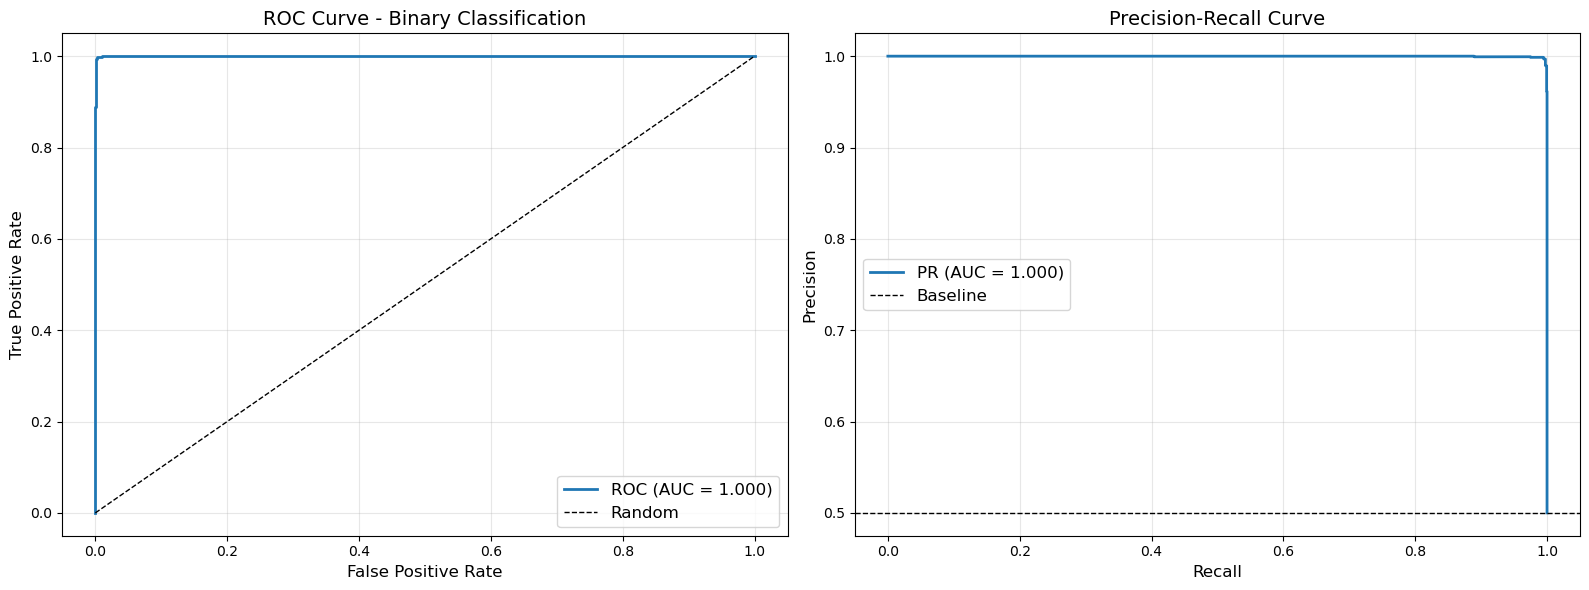

In [30]:
# Plot ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax1.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve - Binary Classification', fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Precision-Recall Curve
ax2.plot(recall, precision, linewidth=2, label=f'PR (AUC = {pr_auc:.3f})')
ax2.axhline(y=np.mean(y_test), color='k', linestyle='--', linewidth=1, label='Baseline')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve', fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Confusion matrix, without normalization


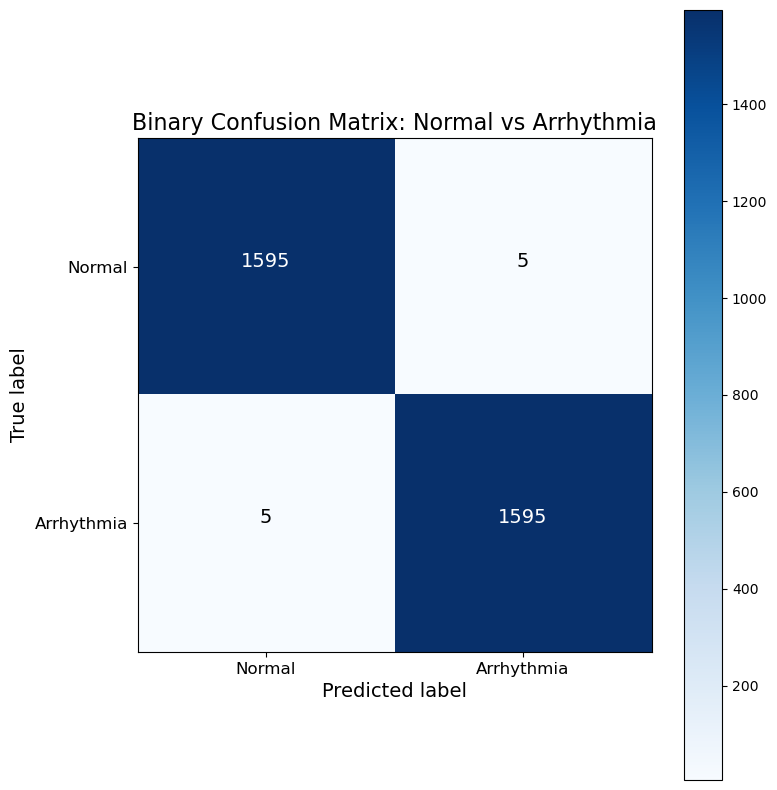

In [31]:
# Binary confusion matrix visualization
def plot_binary_confusion_matrix(cm, normalize=False, title='Binary Confusion Matrix'):
    """
    Plot confusion matrix for binary classification.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title, fontsize=16)
    plt.colorbar()
    
    classes = ['Normal', 'Arrhythmia']
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=12)
    plt.yticks(tick_marks, classes, fontsize=12)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 fontsize=14,
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label', fontsize=14)
    plt.xlabel('Predicted label', fontsize=14)
    plt.tight_layout()
    plt.show()

# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plot_binary_confusion_matrix(cnf_matrix, 
                             title='Binary Confusion Matrix: Normal vs Arrhythmia')